#Задача регрессии

Используется "игрушечный пример": датасет получен в обобщением результатов анкетирования студентов 1-2 курсов. Студенты должны были указать свой рост в см,	размер обуви,	массу в кг,	желаемую зарплату в тыс. руб.,	желаемое число детей. В анкете *специально* присутсвовали переменные, которые, как можно предположить исходя из здравого смысла, не связаны с другими. 

Загрузка данных. 

In [ ]:
from google.colab import files


uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving correg.csv to correg.csv
User uploaded file "correg.csv" with length 2218 bytes


Импорт необходимых модулей

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression as lm

#Разведочный анализ датасета и визуализация данных

Считывание данных в датафрейм, информация о нем и просмотр его верхней части

In [ ]:
df = pd.read_csv('correg.csv', sep=";", encoding='utf_8')
df.info()
df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Рост, см                      126 non-null    int64
 1   Размер обуви                  126 non-null    int64
 2   Масса, кг                     126 non-null    int64
 3   Желаемая зарплата, тыс. руб.  126 non-null    int64
 4   Желаемое число детей          126 non-null    int64
dtypes: int64(5)
memory usage: 5.0 KB


,"Рост, см",Размер обуви,"Масса, кг","Желаемая зарплата, тыс. руб.",Желаемое число детей
0,165,38,55,130,2
1,166,38,58,100,2
2,175,43,65,150,1
3,174,39,55,95,4
4,168,38,42,40,2
5,168,38,47,150,2
6,167,37,47,90,1
7,173,40,60,125,2
8,156,38,55,150,3
9,167,36,59,100,2


Просмотр нижней части датафрейма

In [ ]:
df.tail(n=10)

,"Рост, см",Размер обуви,"Масса, кг","Желаемая зарплата, тыс. руб.",Желаемое число детей
116,176,40,71,500,2
117,170,37,57,100,2
118,172,39,67,100,2
119,168,39,75,100,2
120,157,36,49,450,4
121,170,39,63,500,2
122,164,37,58,500,2
123,180,43,76,50,2
124,166,41,60,60,3
125,160,37,54,80,1


Вывод описательной статистики по датасету

In [ ]:
df.describe()

,"Рост, см",Размер обуви,"Масса, кг","Желаемая зарплата, тыс. руб.",Желаемое число детей
count,126.000000,126.000000,126.00000,126.000000,126.000000
mean,166.420635,38.507937,57.81746,95.357143,2.214286
std,8.889862,2.744437,11.96622,96.143348,0.825660
min,147.000000,34.000000,40.00000,7.000000,0.000000
25%,160.250000,37.000000,49.00000,50.000000,2.000000
50%,165.000000,38.000000,55.00000,70.000000,2.000000
75%,172.000000,40.000000,63.00000,100.000000,2.000000
max,195.000000,50.000000,107.00000,500.000000,7.000000


Парные диаграммы №1

<Figure size 1350x1350 with 0 Axes>

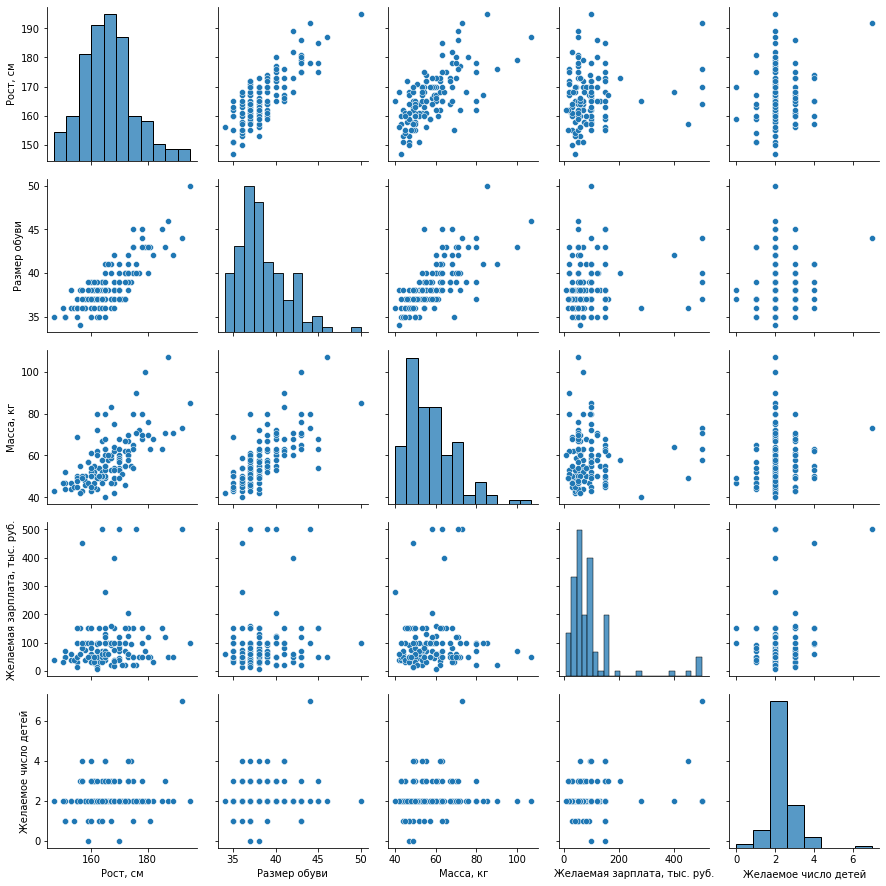

In [ ]:
plt.figure(figsize=(15,15), dpi=90)
sns.pairplot(df, kind="scatter")

Парные диаграммы №2

/usr/local/lib/python3.6/dist-packages/seaborn/distributions.py:305: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.6/dist-packages/seaborn/distributions.py:305: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.6/dist-packages/seaborn/distributions.py:305: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.6/dist-packages/seaborn/distributions.py:305: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


<Figure size 1350x1350 with 0 Axes>

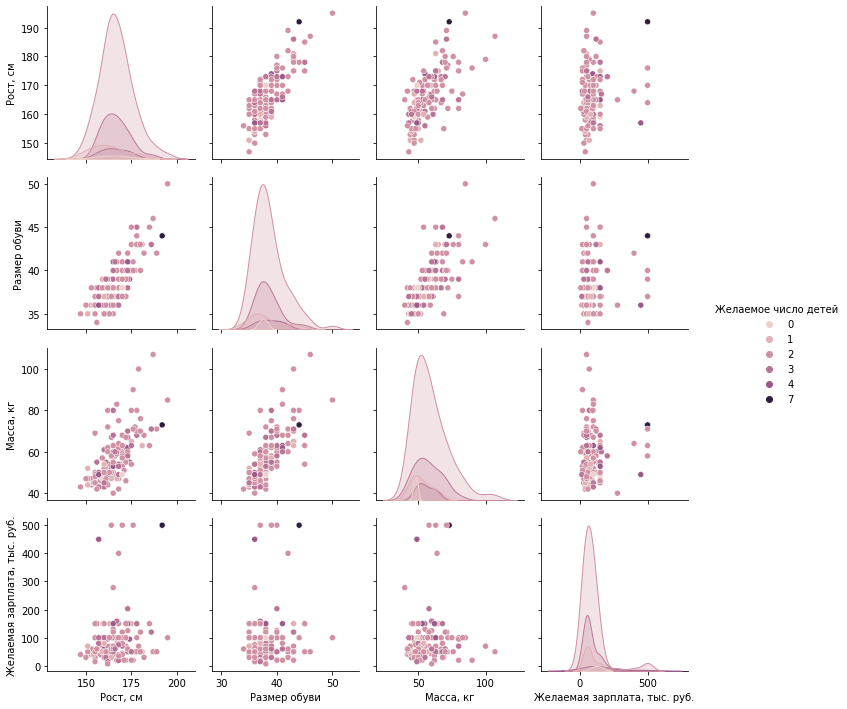

In [ ]:
plt.figure(figsize=(15,15), dpi=90)
sns.pairplot(df, kind="scatter", hue = "Желаемое число детей")

Корреляционная матрица

In [ ]:
df.corr(method='pearson')


,"Рост, см",Размер обуви,"Масса, кг","Желаемая зарплата, тыс. руб.",Желаемое число детей
"Рост, см",1.000000,0.808628,0.656953,0.174031,0.179447
Размер обуви,0.808628,1.000000,0.715136,0.114853,0.128106
"Масса, кг",0.656953,0.715136,1.000000,0.076492,0.099537
"Желаемая зарплата, тыс. руб.",0.174031,0.114853,0.076492,1.000000,0.252588
Желаемое число детей,0.179447,0.128106,0.099537,0.252588,1.000000


Диаграмма корреляции

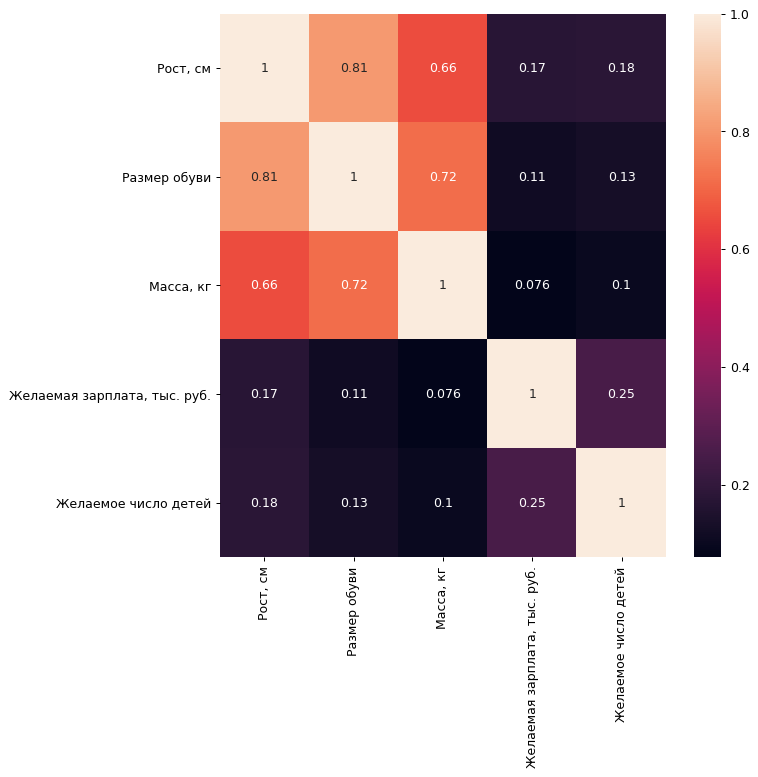

In [ ]:
plt.figure(figsize=(8,8), dpi=90)
sns.heatmap(df.corr(), xticklabels=df.corr().columns, yticklabels=df.corr().columns, annot=True)

Диаграмма рассеяния

Text(0, 0.5, 'Размер обуви')

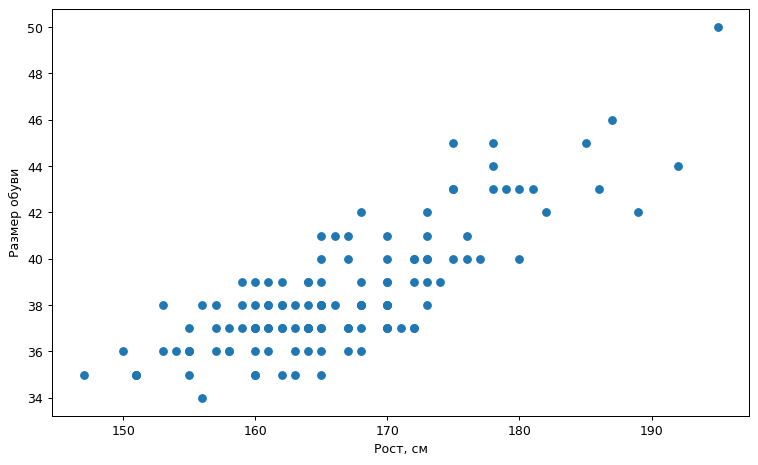

In [ ]:
plt.figure(figsize=(10,6), dpi=90)
plt.scatter(df['Рост, см'], df['Размер обуви'])
plt.xlabel('Рост, см')
plt.ylabel('Размер обуви')

#Построение модели линейной регрессии

$y = a_0 + a_1x$ - уравнение прямой

Выделение зависимой (целевой) переменной y

In [ ]:
y = df['Размер обуви']

y=y.values

Выделение независимой переменной-предиктора X

In [ ]:
X = pd.DataFrame(df['Рост, см'])
print(X.shape)
X.head(20)

(126, 1)


,"Рост, см"
0,165
1,166
2,175
3,174
4,168
5,168
6,167
7,173
8,156
9,167


Разобъем датасет на обучающую и тестовую выборки

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

Строим регрессионную (линейную) модель по обучающей выборке:

In [ ]:
model = lm()
model.fit(X_train, y_train)

print('a1:', *model.coef_)
print('a0: {:.2f}'.format(model.intercept_))

a1: 0.24045564877842854
a0: -1.51


Диаграмма рассеяния данных обучающей выборки с полученной прямой

Text(0, 0.5, 'Размер обуви')

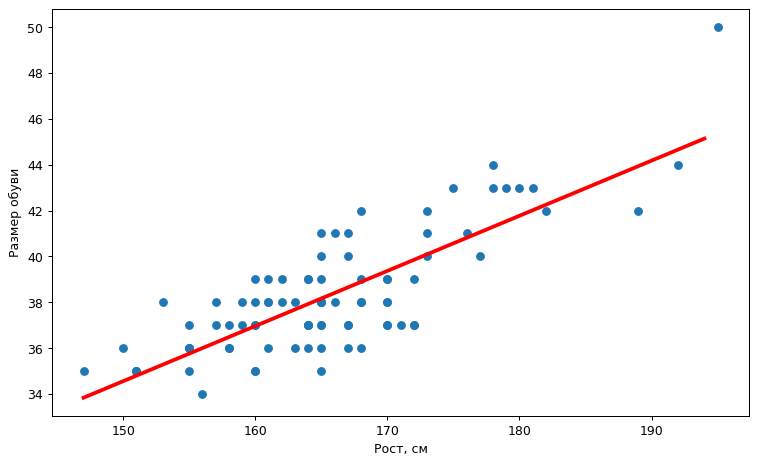

In [ ]:
plt.figure(figsize=(10,6), dpi=90)
plt.scatter(X_train, y_train)
x  = np.arange(np.min(X_train).values, np.max(X_train).values,  1)
y = model.coef_[0]*x + model.intercept_
plt.plot(x,y, color = 'red', lw = 3)
plt.xlabel('Рост, см')
plt.ylabel('Размер обуви')

Прогноз на тестовой выборке

In [ ]:
y_pred = model.predict(X_test)

for i in range(len(y_pred)): print('i=', i, '| Размер обуви факт=', y_test[i],'| Размер обуви предсказ=', y_pred[i],'| Размер обуви дельта=', y_test[i]-y_pred[i])

i= 0 | Размер обуви факт= 38 | Размер обуви предсказ= 36.0006299139887 | Размер обуви дельта= 1.9993700860112966
i= 1 | Размер обуви факт= 37 | Размер обуви предсказ= 39.3670089968867 | Размер обуви дельта= -2.367008996886703
i= 2 | Размер обуви факт= 38 | Размер обуви предсказ= 40.08837594322199 | Размер обуви дельта= -2.0883759432219904
i= 3 | Размер обуви факт= 40 | Размер обуви предсказ= 39.3670089968867 | Размер обуви дельта= 0.6329910031132968
i= 4 | Размер обуви факт= 38 | Размер обуви предсказ= 38.88609769932985 | Размер обуви дельта= -0.8860976993298522
i= 5 | Размер обуви факт= 35 | Размер обуви предсказ= 37.68381945543771 | Размер обуви дельта= -2.683819455437707
i= 6 | Размер обуви факт= 41 | Размер обуви предсказ= 39.3670089968867 | Размер обуви дельта= 1.6329910031132968
i= 7 | Размер обуви факт= 37 | Размер обуви предсказ= 37.44336380665928 | Размер обуви дельта= -0.44336380665927777
i= 8 | Размер обуви факт= 40 | Размер обуви предсказ= 40.08837594322199 | Размер обуви д

Оценим качество предсказания

RMSE_test = 1.642


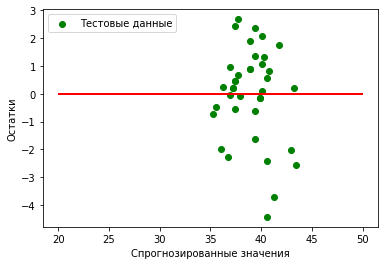

In [ ]:
from sklearn.metrics import mean_squared_error

print('RMSE_test = {:.3f}'.format(
        np.sqrt(mean_squared_error(y_test, y_pred))))

plt.scatter(y_pred,  y_pred - y_test,
            c='green', marker='o', label='Тестовые данные')
plt.xlabel('Спрогнозированные значения')
plt.ylabel('Остатки')
plt.legend(loc='upper left')
plt.hlines(y=0, xmin=20, xmax=50, lw=2, color='red')


#Модель линейной регрессии с несколькими предикторами

Построим более сложную регрессионную модель $y = a_0 + a_1x_1 + a_2x_2 + a_3x_3 + a_4x_4 + ...$ - уравнение прямой в многомерном пространстве.

Выделение зависимой (целевой) переменной y



In [ ]:
y = df['Размер обуви']

y=y.values

Выделение независимых переменных-предикторов X

In [ ]:
X = df.drop(['Размер обуви'], axis=1)
print(X.shape)
X.head(20)

(126, 4)


,"Рост, см","Масса, кг","Желаемая зарплата, тыс. руб.",Желаемое число детей
0,165,55,130,2
1,166,58,100,2
2,175,65,150,1
3,174,55,95,4
4,168,42,40,2
5,168,47,150,2
6,167,47,90,1
7,173,60,125,2
8,156,55,150,3
9,167,59,100,2


Разобъем датасет на обучающую и тестовую выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

Строим регрессионную (линейную) модель по обучающей выборке:

In [ ]:
model = lm()
model.fit(X_train, y_train)

print('a[1-...]: ', model.coef_)
print('a0: {:.2f}'.format(model.intercept_))

a[1-...]:  [ 0.16528956  0.08549139 -0.00049403  0.09815083]
a0: 5.86


Сделаем прогноз на тестовой выборке

In [ ]:
y_pred = model.predict(X_test)

for i in range(len(y_pred)): print('i=', i, '| Размер обуви факт=', y_test[i],'| Размер обуви предсказ=', y_pred[i],'| Размер обуви дельта=', y_test[i]-y_pred[i])

i= 0 | Размер обуви факт= 38 | Размер обуви предсказ= 36.56933812767897 | Размер обуви дельта= 1.430661872321032
i= 1 | Размер обуви факт= 37 | Размер обуви предсказ= 38.66860136327625 | Размер обуви дельта= -1.6686013632762524
i= 2 | Размер обуви факт= 38 | Размер обуви предсказ= 40.45456013174718 | Размер обуви дельта= -2.4545601317471792
i= 3 | Размер обуви факт= 40 | Размер обуви предсказ= 39.2373995003145 | Размер обуви дельта= 0.7626004996854974
i= 4 | Размер обуви факт= 38 | Размер обуви предсказ= 38.418882121256644 | Размер обуви дельта= -0.4188821212566438
i= 5 | Размер обуви факт= 35 | Размер обуви предсказ= 37.225458617809 | Размер обуви дельта= -2.2254586178089966
i= 6 | Размер обуви факт= 41 | Размер обуви предсказ= 39.931211195822094 | Размер обуви дельта= 1.0687888041779061
i= 7 | Размер обуви факт= 37 | Размер обуви предсказ= 39.6273810195472 | Размер обуви дельта= -2.627381019547201
i= 8 | Размер обуви факт= 40 | Размер обуви предсказ= 39.72091751233763 | Размер обуви 

Оценим качество предсказания

RMSE_test = 1.649


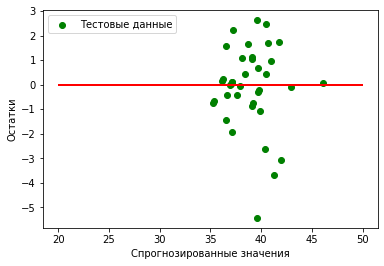

In [ ]:
print('RMSE_test = {:.3f}'.format(
        np.sqrt(mean_squared_error(y_test, y_pred))))

plt.scatter(y_pred,  y_pred - y_test,
            c='green', marker='o', label='Тестовые данные')
plt.xlabel('Спрогнозированные значения')
plt.ylabel('Остатки')
plt.legend(loc='upper left')
plt.hlines(y=0, xmin=20, xmax=50, lw=2, color='red')

#Другие регрессионные методы 

**Деревья решений**

![Дерево решений](https://studref.com/im/13/5014/398643-20.jpg)

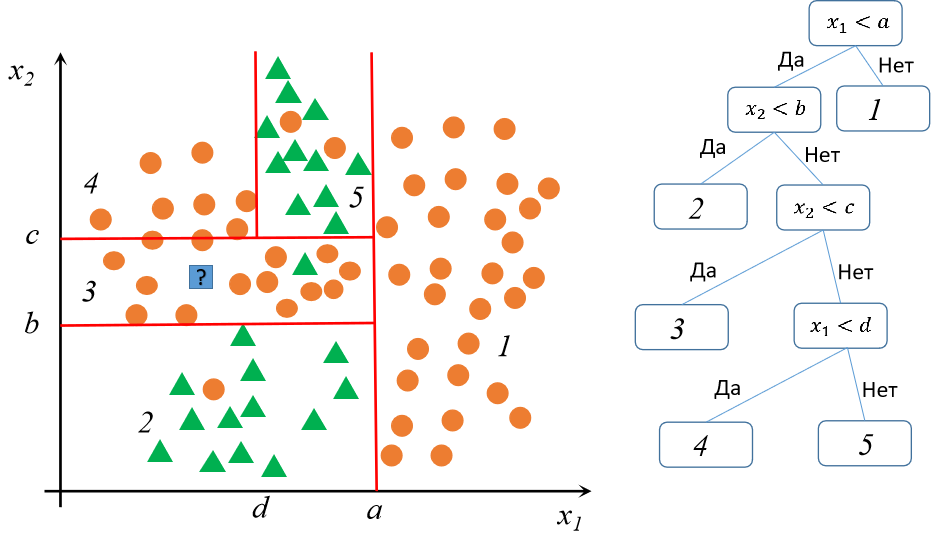



Построение модели деревьев решений и предсказание с ее помощью

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(random_state=42,max_depth=5)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
for i in range (len(y_pred)): print("i=", i," | y_pred=", y_pred[i]," | y_test=", y_test[i], " | y_pred - y_test=", y_pred[i] - y_test[i])


i= 0  | y_pred= 38.0  | y_test= 38  | y_pred - y_test= 0.0
i= 1  | y_pred= 37.125  | y_test= 37  | y_pred - y_test= 0.125
i= 2  | y_pred= 41.0  | y_test= 38  | y_pred - y_test= 3.0
i= 3  | y_pred= 37.125  | y_test= 40  | y_pred - y_test= -2.875
i= 4  | y_pred= 37.125  | y_test= 38  | y_pred - y_test= -0.875
i= 5  | y_pred= 36.666666666666664  | y_test= 35  | y_pred - y_test= 1.6666666666666643
i= 6  | y_pred= 39.77777777777778  | y_test= 41  | y_pred - y_test= -1.2222222222222214
i= 7  | y_pred= 38.666666666666664  | y_test= 37  | y_pred - y_test= 1.6666666666666643
i= 8  | y_pred= 41.0  | y_test= 40  | y_pred - y_test= 1.0
i= 9  | y_pred= 41.0  | y_test= 40  | y_pred - y_test= 1.0
i= 10  | y_pred= 44.0  | y_test= 45  | y_pred - y_test= -1.0
i= 11  | y_pred= 37.6  | y_test= 37  | y_pred - y_test= 0.6000000000000014
i= 12  | y_pred= 44.0  | y_test= 43  | y_pred - y_test= 1.0
i= 13  | y_pred= 36.666666666666664  | y_test= 36  | y_pred - y_test= 0.6666666666666643
i= 14  | y_pred= 42.0  |

Оценим качество предсказания модели деревьев решений

In [ ]:
print ('RMSE=', np.sqrt(mean_squared_error(y_pred,y_test)))

RMSE= 1.9848457814533969


**Ансамблевые методы. RandomForest - случаный лес**

В 1906 году известный британский ученый Френсис Гальтон попал на сельскую ярмарку, на которой в качестве развлечения посетителям предлагалось на глаз оценить вес выставленного на всеобщее обозрение быка и написать эту цифру на специальном билете. За правильные ответы организаторы шоу обещали призы. В результате в голосовании приняли участие около 800 человек — как заядлых фермеров, так и людей, далеких от скотоводческих дел. Собрав после этой ярмарки все билеты для анализа, Гальтон высчитал среднее арифметическое значение для всей выборки — 1197 фунтов. Реальный же вес быка оказался 1198 фунтов. Каким-то непостижимым образом разношерстная публика дала ответ, максимально приближенный к реальному показателю.

![RandomForest](https://cdn.analyticsvidhya.com/wp-content/uploads/2020/02/rfc_vs_dt1.png)

Построение модели случаного леса и предсказание с ее помощью

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model1 =  RandomForestRegressor(n_estimators=10 ,
                               oob_score=True,
                               random_state=1)
model1.fit(X_train, y_train) 
y_pred = model1.predict(X_test) 


for i in range (len(y_pred)): print("i=", i," | y_pred=", y_pred[i]," | y_test=", y_test[i], " | y_pred - y_test=", y_pred[i] - y_test[i])

i= 0  | y_pred= 37.7  | y_test= 38  | y_pred - y_test= -0.29999999999999716
i= 1  | y_pred= 38.1  | y_test= 37  | y_pred - y_test= 1.1000000000000014
i= 2  | y_pred= 41.0  | y_test= 38  | y_pred - y_test= 3.0
i= 3  | y_pred= 37.6  | y_test= 40  | y_pred - y_test= -2.3999999999999986
i= 4  | y_pred= 38.0  | y_test= 38  | y_pred - y_test= 0.0
i= 5  | y_pred= 36.6  | y_test= 35  | y_pred - y_test= 1.6000000000000014
i= 6  | y_pred= 39.3  | y_test= 41  | y_pred - y_test= -1.7000000000000028
i= 7  | y_pred= 38.6  | y_test= 37  | y_pred - y_test= 1.6000000000000014
i= 8  | y_pred= 40.7  | y_test= 40  | y_pred - y_test= 0.7000000000000028
i= 9  | y_pred= 41.5  | y_test= 40  | y_pred - y_test= 1.5
i= 10  | y_pred= 43.2  | y_test= 45  | y_pred - y_test= -1.7999999999999972
i= 11  | y_pred= 38.1  | y_test= 37  | y_pred - y_test= 1.1000000000000014
i= 12  | y_pred= 43.1  | y_test= 43  | y_pred - y_test= 0.10000000000000142
i= 13  | y_pred= 36.0  | y_test= 36  | y_pred - y_test= 0.0
i= 14  | y_pre

Оценка качества предсказания модели RF



In [ ]:
print ('RMSE=', np.sqrt(mean_squared_error(y_pred,y_test)))

RMSE= 1.6117986030649445


**Градиентный бустинг**

Общая идея алгоритмов бустинга - последовательно применять предикторы так, чтобы каждая последующая модель минимизировала ошибку предыдущей.
![Градиентный бустинг](https://lambda-it.ru/media/editor/adabot_20190327103649949086.jpg)

Построение модели XGBoost

In [ ]:
import xgboost
model = xgboost.XGBRegressor(learning_rate=0.07, max_depth=5,iterations=200,seed=0) 
model.fit(X_train,y_train)

[19:28:13] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0,
             importance_type='gain', iterations=200, learning_rate=0.07,
             max_delta_step=0, max_depth=5, min_child_weight=1, missing=None,
             n_estimators=100, n_jobs=1, nthread=None, objective='reg:linear',
             random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=1,
             seed=0, silent=None, subsample=1, verbosity=1)

Предсказание с помощью XGBoost

In [ ]:
y_pred = model.predict (X_test)
for i in range (len(y_pred)): print("i=", i," | y_pred=", y_pred[i]," | y_test=", y_test[i], " | y_pred - y_test=", y_pred[i] - y_test[i])


i= 0  | y_pred= 35.919865  | y_test= 38  | y_pred - y_test= -2.0801353454589844
i= 1  | y_pred= 38.512745  | y_test= 37  | y_pred - y_test= 1.5127449035644531
i= 2  | y_pred= 41.63021  | y_test= 38  | y_pred - y_test= 3.6302108764648438
i= 3  | y_pred= 38.91071  | y_test= 40  | y_pred - y_test= -1.0892906188964844
i= 4  | y_pred= 37.823086  | y_test= 38  | y_pred - y_test= -0.17691421508789062
i= 5  | y_pred= 36.790695  | y_test= 35  | y_pred - y_test= 1.7906951904296875
i= 6  | y_pred= 39.54093  | y_test= 41  | y_pred - y_test= -1.4590682983398438
i= 7  | y_pred= 38.9893  | y_test= 37  | y_pred - y_test= 1.9892997741699219
i= 8  | y_pred= 40.92815  | y_test= 40  | y_pred - y_test= 0.9281501770019531
i= 9  | y_pred= 41.649197  | y_test= 40  | y_pred - y_test= 1.6491966247558594
i= 10  | y_pred= 42.537216  | y_test= 45  | y_pred - y_test= -2.4627838134765625
i= 11  | y_pred= 36.87865  | y_test= 37  | y_pred - y_test= -0.12134933471679688
i= 12  | y_pred= 42.212353  | y_test= 43  | y_pre

Оценка качества предсказания XGBoost

In [ ]:
print ('RMSE=', np.sqrt(mean_squared_error(y_pred,y_test)))

RMSE= 1.7762570881623516


Построение модели CatBoost и предсказание с ее помощью

In [ ]:
!pip install catboost
from catboost import CatBoostRegressor

model2 = CatBoostRegressor(iterations=346, learning_rate=0.05, depth=5)
# Fit model
model2.fit(X_train, y_train)
# Get predictions
y_pred = model2.predict(X_test)

     |████████████████████████████████| 66.2MB 57kB/s 
0:	learn: 2.6104762	total: 46.4ms	remaining: 16s
1:	learn: 2.5608885	total: 47ms	remaining: 8.09s
2:	learn: 2.4984650	total: 47.5ms	remaining: 5.43s
3:	learn: 2.4487863	total: 48.2ms	remaining: 4.12s
4:	learn: 2.4012185	total: 48.6ms	remaining: 3.31s
5:	learn: 2.3575113	total: 48.9ms	remaining: 2.77s
6:	learn: 2.3070216	total: 49.3ms	remaining: 2.39s
7:	learn: 2.2500312	total: 49.6ms	remaining: 2.1s
8:	learn: 2.2030973	total: 50ms	remaining: 1.87s
9:	learn: 2.1636026	total: 50.4ms	remaining: 1.69s
10:	learn: 2.1180148	total: 50.7ms	remaining: 1.54s
11:	learn: 2.0821074	total: 51ms	remaining: 1.42s
12:	learn: 2.0411511	total: 51.4ms	remaining: 1.32s
13:	learn: 2.0117409	total: 51.7ms	remaining: 1.23s
14:	learn: 1.9834590	total: 52.1ms	remaining: 1.15s
15:	learn: 1.9523677	total: 52.4ms	remaining: 1.08s
16:	learn: 1.9160895	total: 52.7ms	remaining: 1.02s
17:	learn: 1.8883503	total: 53ms	remaining: 966ms
18:	learn: 1.8567138	total: 53

In [ ]:
for i in range (len(y_pred)): print("i=", i," | y_pred=", y_pred[i]," | y_test=", y_test[i], " | y_pred - y_test=", y_pred[i] - y_test[i])


i= 0  | y_pred= 37.03949381219269  | y_test= 38  | y_pred - y_test= -0.9605061878073116
i= 1  | y_pred= 37.7222329825359  | y_test= 37  | y_pred - y_test= 0.7222329825358997
i= 2  | y_pred= 41.152812791272154  | y_test= 38  | y_pred - y_test= 3.1528127912721544
i= 3  | y_pred= 38.368518257660774  | y_test= 40  | y_pred - y_test= -1.6314817423392256
i= 4  | y_pred= 37.75179805127611  | y_test= 38  | y_pred - y_test= -0.24820194872388868
i= 5  | y_pred= 36.48049459206391  | y_test= 35  | y_pred - y_test= 1.4804945920639128
i= 6  | y_pred= 39.12022996263978  | y_test= 41  | y_pred - y_test= -1.8797700373602169
i= 7  | y_pred= 39.05650857747425  | y_test= 37  | y_pred - y_test= 2.056508577474247
i= 8  | y_pred= 40.780833025757595  | y_test= 40  | y_pred - y_test= 0.7808330257575946
i= 9  | y_pred= 41.61202011491788  | y_test= 40  | y_pred - y_test= 1.6120201149178826
i= 10  | y_pred= 42.64136086083611  | y_test= 45  | y_pred - y_test= -2.3586391391638912
i= 11  | y_pred= 37.187122186558696

Оценка качества модели CatBoost 

In [ ]:
print ('RMSE=', np.sqrt(mean_squared_error(y_pred,y_test)))

RMSE= 1.5790287126540437
